In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime, timedelta

# Sklearn untuk Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [17]:
df = pd.read_csv('data_aqi.csv')
df.head()

,No,Timestamp,PM2.5 raw,PM2.5 density,PM10 density,Air quality level,Temperature,Humidity,Pressure,Altitude estimate,Device ID
0,1,2020-12-05 22:00:00,0.9,1.0,2.2,BAIK,25.4,80.1,940.0,628.8,10:B4:1D:E8:2E:E4
1,2,2020-12-05 22:00:30,0.5,1.0,2.0,BAIK,24.1,85.0,940.3,626.5,10:B4:1D:E8:2E:E4
2,3,2020-12-05 22:01:00,3.6,5.2,7.8,BAIK,25.3,84.6,940.7,623.1,10:B4:1D:E8:2E:E4
3,4,2020-12-05 22:01:30,0.7,1.3,3.2,BAIK,24.4,83.1,938.9,630.0,10:B4:1D:E8:2E:E4
4,5,2020-12-05 22:02:00,2.8,3.0,4.5,BAIK,27.4,78.5,939.4,630.0,10:B4:1D:E8:2E:E4


In [18]:
df.drop(['No', 'PM2.5 raw', 'Device ID'], axis=1, inplace=True)

In [19]:
df['Air quality level'].value_counts()

Air quality level
BAIK                  599097
SEDANG                250302
TIDAK SEHAT           100613
SANGAT TIDAK SEHAT     40138
BERBAHAYA               9850
Name: count, dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Timestamp          1000000 non-null  object 
 1   PM2.5 density      1000000 non-null  float64
 2   PM10 density       1000000 non-null  float64
 3   Air quality level  1000000 non-null  object 
 4   Temperature        1000000 non-null  float64
 5   Humidity           1000000 non-null  float64
 6   Pressure           1000000 non-null  float64
 7   Altitude estimate  1000000 non-null  float64
dtypes: float64(6), object(2)
memory usage: 61.0+ MB


In [21]:
# Tabel Breakpoint ISPU Resmi Indonesia
BREAKPOINTS = {
    'PM25': [
        [0.0, 15.5, 0, 50],         # Baik
        [15.6, 55.4, 51, 100],      # Sedang
        [55.5, 150.4, 101, 200],    # Tidak Sehat
        [150.5, 250.4, 201, 300],   # Sangat Tidak Sehat
        [250.5, 500.0, 301, 500]    # Berbahaya
    ],
    'PM10': [
        [0, 50, 0, 50],             # Baik
        [51, 150, 51, 100],         # Sedang
        [151, 350, 101, 200],       # Tidak Sehat
        [351, 420, 201, 300],       # Sangat Tidak Sehat
        [421, 10000, 301, 500]      # Berbahaya
    ]
}

def hitung_ispu(konsentrasi, polutan='PM25'):
    """
    Menghitung ISPU menggunakan interpolasi linear.

    Rumus: ISPU = [(Iu - Il) / (Xu - Xl)] × (Xx - Xl) + Il
    """
    if konsentrasi < 0:
        return 0.0

    breakpoints = BREAKPOINTS[polutan]

    for bp in breakpoints:
        Xl, Xu, Il, Iu = bp
        if Xl <= konsentrasi <= Xu:
            ispu = ((Iu - Il) / (Xu - Xl)) * (konsentrasi - Xl) + Il
            return round(ispu, 2)

    return 500.0

# Test fungsi
print("Test ISPU Calculator:")
print(f"PM2.5 = 25.0 µg/m³ → ISPU = {hitung_ispu(25.0, 'PM25')}")
print(f"PM10 = 80.0 µg/m³ → ISPU = {hitung_ispu(80.0, 'PM10')}")

Test ISPU Calculator:
PM2.5 = 25.0 µg/m³ → ISPU = 62.57
PM10 = 80.0 µg/m³ → ISPU = 65.35


In [22]:
# Load data
df_raw =df.copy()

# Lowercase kolom
df_raw.columns = df_raw.columns.str.lower().str.replace(' ', '_')

# Parse timestamp
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw = df_raw.sort_values('timestamp').reset_index(drop=True)

print("📊 Data Overview:")
print(f"Shape: {df_raw.shape}")
print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nTime range: {df_raw['timestamp'].min()} to {df_raw['timestamp'].max()}")
print(f"\nMissing values:")
print(df_raw.isnull().sum())

📊 Data Overview:
Shape: (1000000, 8)

Columns: ['timestamp', 'pm2.5_density', 'pm10_density', 'air_quality_level', 'temperature', 'humidity', 'pressure', 'altitude_estimate']

Time range: 2020-12-05 22:00:00 to 2021-11-18 03:19:30

Missing values:
timestamp            0
pm2.5_density        0
pm10_density         0
air_quality_level    0
temperature          0
humidity             0
pressure             0
altitude_estimate    0
dtype: int64


In [23]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   timestamp          1000000 non-null  datetime64[ns]
 1   pm2.5_density      1000000 non-null  float64       
 2   pm10_density       1000000 non-null  float64       
 3   air_quality_level  1000000 non-null  object        
 4   temperature        1000000 non-null  float64       
 5   humidity           1000000 non-null  float64       
 6   pressure           1000000 non-null  float64       
 7   altitude_estimate  1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 61.0+ MB


In [24]:
# Data Cleaning
# 1. Handle outliers dengan IQR method
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR

        outliers = (df_clean[col] < lower) | (df_clean[col] > upper)
        n_outliers = outliers.sum()

        if n_outliers > 0:
            df_clean.loc[outliers, col] = np.nan
            print(f"  Removed {n_outliers} outliers from {col}")

    return df_clean

# 2. Apply cleaning
numeric_cols = ['pm2.5_density', 'pm10_density', 'temperature', 'humidity', 'pressure']
df_clean = remove_outliers_iqr(df_raw, numeric_cols)

# 3. Fill missing values dengan interpolasi
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='linear')

# 4. Resample ke hourly (jika perlu)
df_clean.set_index('timestamp', inplace=True)
df_hourly = df_clean.resample('H').mean(numeric_only=True)
df_hourly = df_hourly.reset_index()

print(f"\n✅ Data cleaned and resampled")
print(f"New shape: {df_hourly.shape}")
print(f"\nNo more missing values: {df_hourly[numeric_cols].isnull().sum().sum() == 0}")

  Removed 75626 outliers from pm2.5_density
  Removed 74676 outliers from pm10_density

✅ Data cleaned and resampled
New shape: (8334, 7)

No more missing values: True


C:\Users\user\AppData\Local\Temp\ipykernel_18860\1730573385.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_clean.resample('H').mean(numeric_only=True)


✅ ISPU calculated

ISPU Statistics:
              ispu    ispu_pm25    ispu_pm10
count  8334.000000  8334.000000  8334.000000
mean     57.275892    56.758331    32.683023
std      37.991170    34.756377    17.954678
min      24.280000    24.280000    12.490000
25%      49.052500    49.052500    25.550000
50%      56.590000    56.590000    33.090000
75%      60.457500    60.457500    38.380000
max     500.000000   500.000000   500.000000


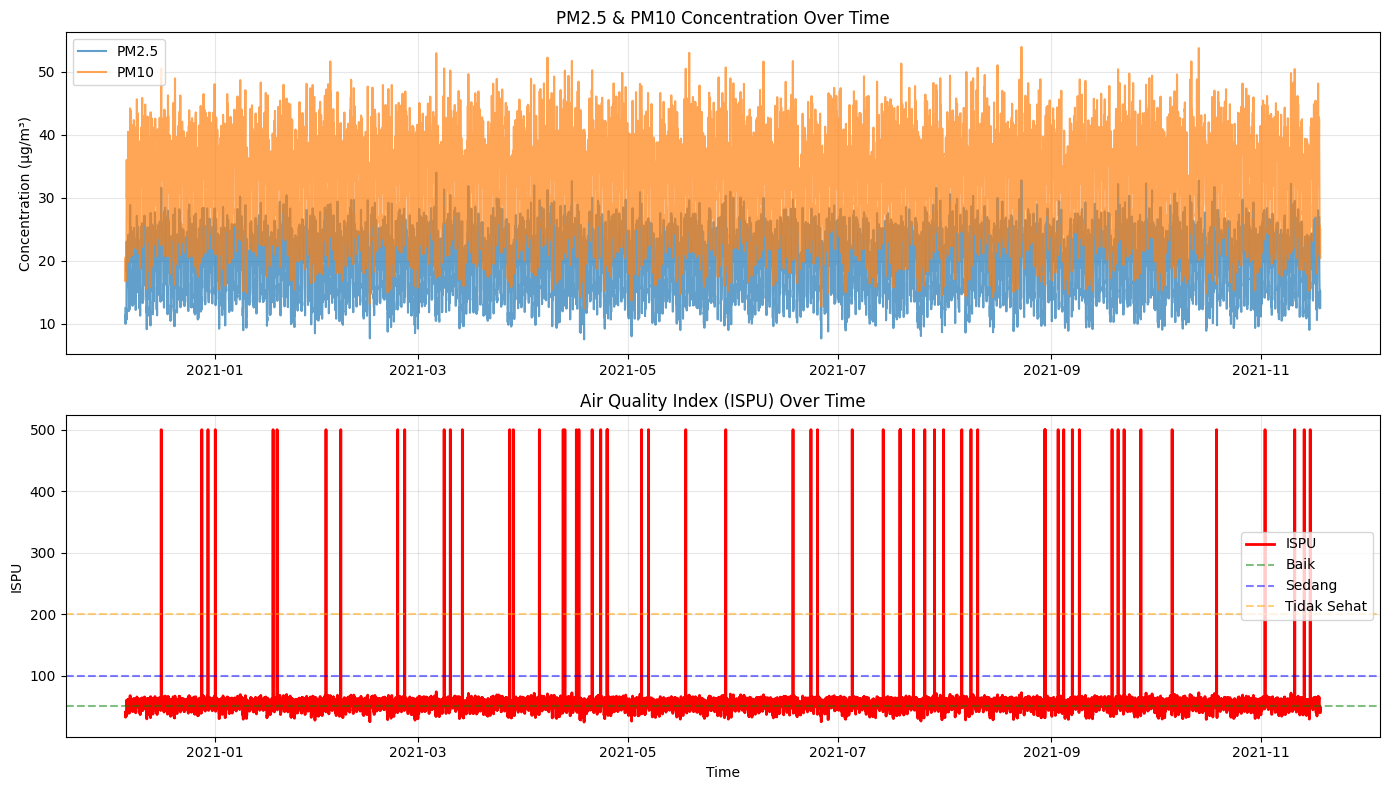

In [25]:
# Hitung ISPU untuk semua data
df_hourly['ispu_pm25'] = df_hourly['pm2.5_density'].apply(lambda x: hitung_ispu(x, 'PM25'))
df_hourly['ispu_pm10'] = df_hourly['pm10_density'].apply(lambda x: hitung_ispu(x, 'PM10'))
df_hourly['ispu'] = df_hourly[['ispu_pm25', 'ispu_pm10']].max(axis=1)

print("✅ ISPU calculated")
print(f"\nISPU Statistics:")
print(df_hourly[['ispu', 'ispu_pm25', 'ispu_pm10']].describe())

# Visualisasi
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot konsentrasi
axes[0].plot(df_hourly['timestamp'], df_hourly['pm2.5_density'], label='PM2.5', alpha=0.7)
axes[0].plot(df_hourly['timestamp'], df_hourly['pm10_density'], label='PM10', alpha=0.7)
axes[0].set_ylabel('Concentration (µg/m³)')
axes[0].set_title('PM2.5 & PM10 Concentration Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot ISPU
axes[1].plot(df_hourly['timestamp'], df_hourly['ispu'], label='ISPU', color='red', linewidth=2)
axes[1].axhline(y=50, color='green', linestyle='--', alpha=0.5, label='Baik')
axes[1].axhline(y=100, color='blue', linestyle='--', alpha=0.5, label='Sedang')
axes[1].axhline(y=200, color='orange', linestyle='--', alpha=0.5, label='Tidak Sehat')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('ISPU')
axes[1].set_title('Air Quality Index (ISPU) Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
df_hourly

,timestamp,pm2.5_density,pm10_density,temperature,humidity,pressure,altitude_estimate,ispu_pm25,ispu_pm10,ispu
0,2020-12-05 22:00:00,12.490000,20.466250,26.445833,81.130833,940.597500,624.537500,40.29,20.47,40.29
1,2020-12-05 23:00:00,9.994167,16.723333,26.141667,80.760833,940.504167,624.840833,32.24,16.72,32.24
2,2020-12-06 00:00:00,11.556667,19.307500,25.986667,81.185833,940.643333,624.351667,37.28,19.31,37.28
3,2020-12-06 01:00:00,11.211250,20.372917,26.028333,80.691667,940.503333,625.074167,36.17,20.37,36.17
4,2020-12-06 02:00:00,10.949167,20.409167,26.134167,81.061667,940.483333,624.994167,35.32,20.41,35.32
...,...,...,...,...,...,...,...,...,...,...
8329,2021-11-17 23:00:00,12.453333,20.978333,26.337500,80.814167,940.445833,625.549167,40.17,20.98,40.17
8330,2021-11-18 00:00:00,15.122500,25.485417,25.992500,81.042500,940.476667,625.288333,48.78,25.49,48.78
8331,2021-11-18 01:00:00,12.647083,22.617500,25.905000,81.259167,940.406667,626.080000,40.80,22.62,40.80
8332,2021-11-18 02:00:00,15.270000,25.066250,26.074167,80.213333,940.487500,625.200000,49.26,25.07,49.26


In [27]:
# =============================
# 1) Dataset 30 detik + ISPU
# =============================

# Pastikan index timestamp ada
df_30s = df_clean.copy()
if 'timestamp' not in df_30s.columns:
    df_30s = df_30s.reset_index()

# Hitung ISPU per 30 detik
df_30s['ispu_pm25'] = df_30s['pm2.5_density'].apply(lambda x: hitung_ispu(x, 'PM25'))
df_30s['ispu_pm10'] = df_30s['pm10_density'].apply(lambda x: hitung_ispu(x, 'PM10'))
df_30s['ispu'] = df_30s[['ispu_pm25', 'ispu_pm10']].max(axis=1)

# Sort
df_30s = df_30s.sort_values('timestamp').reset_index(drop=True)

print(df_30s[['timestamp', 'pm2.5_density', 'pm10_density', 'ispu']].head())
print(df_30s[['timestamp', 'pm2.5_density', 'pm10_density', 'ispu']].tail())

            timestamp  pm2.5_density  pm10_density   ispu
0 2020-12-05 22:00:00            1.0           2.2   3.23
1 2020-12-05 22:00:30            1.0           2.0   3.23
2 2020-12-05 22:01:00            5.2           7.8  16.77
3 2020-12-05 22:01:30            1.3           3.2   4.19
4 2020-12-05 22:02:00            3.0           4.5   9.68
                 timestamp  pm2.5_density  pm10_density   ispu
999995 2021-11-18 03:17:30            1.4           3.1   4.52
999996 2021-11-18 03:18:00            5.2           7.2  16.77
999997 2021-11-18 03:18:30            2.7           4.8   8.71
999998 2021-11-18 03:19:00            2.7           3.7   8.71
999999 2021-11-18 03:19:30            1.8           3.3   5.81


In [28]:
# ========================================
# 2) Feature Engineering: ULTRA ADVANCED (EMA + Log Inputs)
# ========================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ====== Resampling ======
RESAMPLE_RULE = "15T"

def _steps_per_hour(rule: str) -> int:
    if rule.endswith("S"): seconds = int(rule[:-1])
    elif rule.endswith("T"): seconds = int(rule[:-1]) * 60
    elif rule.endswith("H"): seconds = int(rule[:-1]) * 3600
    else: raise ValueError("Rule unknown")
    return int(3600 / seconds)

steps_per_hour = _steps_per_hour(RESAMPLE_RULE)
steps_ahead = 48 * steps_per_hour

# Base Data
df_base = df_30s.copy().set_index('timestamp')
df_resampled = df_base.resample(RESAMPLE_RULE).mean(numeric_only=True).reset_index()
df_feat = df_resampled.copy()

# --- 0. Log-Transform pada INPUT Features (PENTING untuk Scaling data Skewed) ---
# Kita log kan PM2.5 dan PM10 sebagai fitur input tambahan
# Ini membantu model melihat pola perubahan persentase, bukan hanya nilai absolut
for col in ['pm2.5_density', 'pm10_density', 'ispu']:
    df_feat[f'log_{col}'] = np.log1p(df_feat[col])

# --- 1. Cyclical Time Features ---
df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['timestamp'].dt.hour / 24)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['timestamp'].dt.hour / 24)
df_feat['day_sin'] = np.sin(2 * np.pi * df_feat['timestamp'].dt.dayofweek / 7)
df_feat['day_cos'] = np.cos(2 * np.pi * df_feat['timestamp'].dt.dayofweek / 7)

# --- 2. Exponential Moving Averages (EMA) ---
# EMA lebih responsif terhadap tren terkini dibanding rolling mean biasa
# Span: 4 steps (~1 jam), 12 steps (~3 jam), 96 steps (~24 jam)
ema_spans = [4, 12, 96]
features_to_ema = ['ispu', 'log_ispu', 'log_pm2.5_density']

for col in features_to_ema:
    for span in ema_spans:
        df_feat[f'{col}_ema_{span}'] = df_feat[col].ewm(span=span, adjust=False).mean()
        
# --- 3. Lags with "Jumps" ---
# Selain lag biasa, kita butuh "Lag Difference" (apakah hari ini lebih tinggi dari kemarin?)
lag_hours = [1, 6, 24, 48]
lag_steps = [int(h * steps_per_hour) for h in lag_hours]

for col in ['ispu', 'log_pm2.5_density']:
    for lag in lag_steps:
        # Lag value
        df_feat[f'{col}_lag_{lag}'] = df_feat[col].shift(lag)
        # Lag Difference (Momentum): Nilai sekarang - Nilai lag
        # Ini memberi tahu model arah pergerakan
        df_feat[f'{col}_diff_{lag}'] = df_feat[col] - df_feat[f'{col}_lag_{lag}']

# --- 4. Volatility (Rolling Std Dev) ---
# Apakah kualitas udara sedang stabil atau bergejolak?
df_feat['volatility_24h'] = df_feat['ispu'].rolling(24*steps_per_hour).std()

# Target: ISPU 48 jam ke depan
df_feat['target_ispu_48h'] = df_feat['ispu'].shift(-steps_ahead)

# Drop NA
df_feat = df_feat.dropna().reset_index(drop=True)

# Prep X, y
feature_cols = [c for c in df_feat.columns if c not in ['timestamp', 'target_ispu_48h']]
X = df_feat[feature_cols]
y = df_feat['target_ispu_48h']

print(f"Features created: {len(feature_cols)}")
print("Sample features:", feature_cols[:5])
X.head(3)

C:\Users\user\AppData\Local\Temp\ipykernel_18860\3163889667.py:24: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df_base.resample(RESAMPLE_RULE).mean(numeric_only=True).reset_index()


Features created: 42
Sample features: ['pm2.5_density', 'pm10_density', 'temperature', 'humidity', 'pressure']


,pm2.5_density,pm10_density,temperature,humidity,pressure,altitude_estimate,ispu_pm25,ispu_pm10,ispu,log_pm2.5_density,...,ispu_diff_192,log_pm2.5_density_lag_4,log_pm2.5_density_diff_4,log_pm2.5_density_lag_24,log_pm2.5_density_diff_24,log_pm2.5_density_lag_96,log_pm2.5_density_diff_96,log_pm2.5_density_lag_192,log_pm2.5_density_diff_192,volatility_24h
0,14.081667,22.545000,25.603333,81.013333,940.333333,625.713333,34.696667,35.920667,49.110333,2.713480,...,27.026667,3.167583,-0.454103,3.254565,-0.541085,2.572103,0.141377,2.071493,0.641987,11.224302
1,19.863333,31.920000,26.043333,80.243333,940.450000,625.560000,42.739333,27.164333,42.739333,3.037993,...,13.451333,3.106975,-0.068982,3.200848,-0.162854,2.629247,0.408746,2.526528,0.511465,11.123102
2,12.493333,20.036667,26.230000,80.636667,940.816667,623.833333,32.815667,19.471000,32.815667,2.602196,...,-3.269000,3.341211,-0.739016,3.142139,-0.539943,2.529189,0.073006,2.816207,-0.214011,11.044001


In [29]:
# Prepare data untuk Ridge Regression
print("="*70)
print("TRAINING RIDGE REGRESSION - PM2.5 IMPUTATION")
print("="*70)

# Features dan target
feature_cols = ['pm10_density', 'temperature', 'humidity', 'pressure']
X_imputer = df_hourly[feature_cols].copy()
y_imputer = df_hourly['pm2.5_density'].copy()

print(f"\n📊 Training data: {len(X_imputer)} samples")
print(f"Features: {feature_cols}")

# Train-test split (80-20)
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_imputer, y_imputer, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train_imp)} | Test: {len(X_test_imp)}")

# Standardization
scaler_ridge = StandardScaler()
X_train_scaled = scaler_ridge.fit_transform(X_train_imp)
X_test_scaled = scaler_ridge.transform(X_test_imp)

# Training Ridge Regression
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train_imp)

print("\n✅ Ridge Regression trained!")

# Evaluation
y_train_pred = ridge_model.predict(X_train_scaled)
y_test_pred = ridge_model.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train_imp, y_train_pred))
train_mae = mean_absolute_error(y_train_imp, y_train_pred)
train_r2 = r2_score(y_train_imp, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test_imp, y_test_pred))
test_mae = mean_absolute_error(y_test_imp, y_test_pred)
test_r2 = r2_score(y_test_imp, y_test_pred)

print(f"\n📈 Performance:")
print(f"Training   - RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R²: {train_r2:.4f}")
print(f"Test       - RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}")

# Feature importance (coefficients)
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': ridge_model.coef_,
    'abs_coef': np.abs(ridge_model.coef_)
}).sort_values('abs_coef', ascending=False)

print(f"\n📊 Feature Importance (Coefficients):")
print(importance_df.to_string(index=False))

TRAINING RIDGE REGRESSION - PM2.5 IMPUTATION

📊 Training data: 8334 samples
Features: ['pm10_density', 'temperature', 'humidity', 'pressure']
Train: 6667 | Test: 1667

✅ Ridge Regression trained!

📈 Performance:
Training   - RMSE: 0.9750 | MAE: 0.6650 | R²: 0.9590
Test       - RMSE: 0.9715 | MAE: 0.6662 | R²: 0.9585

📊 Feature Importance (Coefficients):
     feature  coefficient  abs_coef
pm10_density     4.661041  4.661041
    humidity    -0.053953  0.053953
 temperature     0.048277  0.048277
    pressure    -0.005236  0.005236


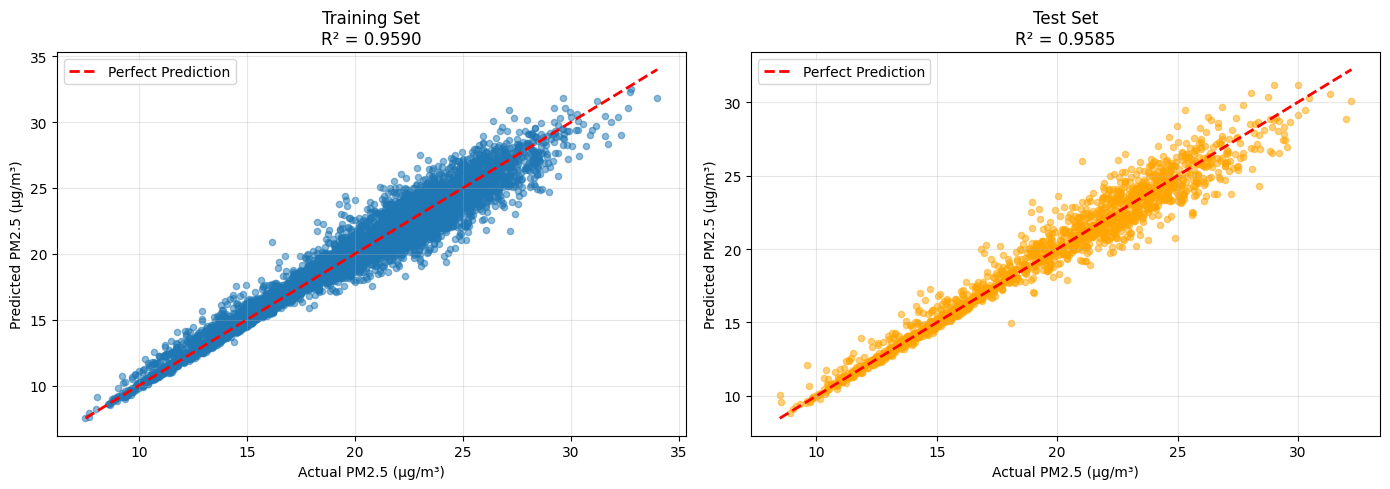


🧪 Test Single Prediction:
Input: PM10=80.0, Temp=28.5°C
Predicted PM2.5: 43.12 µg/m³


In [30]:
# Visualisasi Ridge Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot - Training
axes[0].scatter(y_train_imp, y_train_pred, alpha=0.5, s=20)
axes[0].plot([y_train_imp.min(), y_train_imp.max()],
             [y_train_imp.min(), y_train_imp.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual PM2.5 (µg/m³)')
axes[0].set_ylabel('Predicted PM2.5 (µg/m³)')
axes[0].set_title(f'Training Set\nR² = {train_r2:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter plot - Test
axes[1].scatter(y_test_imp, y_test_pred, alpha=0.5, s=20, color='orange')
axes[1].plot([y_test_imp.min(), y_test_imp.max()],
             [y_test_imp.min(), y_test_imp.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual PM2.5 (µg/m³)')
axes[1].set_ylabel('Predicted PM2.5 (µg/m³)')
axes[1].set_title(f'Test Set\nR² = {test_r2:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test imputation dengan single input
print("\n🧪 Test Single Prediction:")
test_input = {
    'pm10_density': 80.0,
    'temperature': 28.5,
    'humidity': 65.0,
    'pressure': 1013.0
}

test_scaled = scaler_ridge.transform(pd.DataFrame([test_input]))
predicted_pm25 = ridge_model.predict(test_scaled)[0]

print(f"Input: PM10={test_input['pm10_density']}, Temp={test_input['temperature']}°C")
print(f"Predicted PM2.5: {predicted_pm25:.2f} µg/m³")

# 🎯 ANOMALY DETECTION & DATA IMPUTATION SYSTEM

Sistem ini akan:
1. **Deteksi anomali** pada PM2.5 dan PM10 menggunakan Z-score dan IQR
2. **Imputation otomatis** untuk nilai yang error/abnormal
3. **Model terpisah** untuk PM2.5 dan PM10
4. **Save models** untuk deployment di production

In [31]:
# ========================================
# STEP 1: ANOMALY DETECTION FUNCTIONS
# ========================================

def detect_anomaly(value, mean, std, iqr_low, iqr_high, method='combined'):
    """
    Deteksi apakah nilai adalah anomali/tidak normal
    
    Parameters:
    - value: nilai yang akan dicek
    - mean, std: untuk Z-score method
    - iqr_low, iqr_high: batas IQR
    - method: 'zscore', 'iqr', atau 'combined'
    
    Returns:
    - True jika anomali, False jika normal
    """
    if pd.isna(value) or value < 0:
        return True
    
    # Z-score method (nilai > 3 std dari mean)
    z_score = abs((value - mean) / std) if std > 0 else 0
    is_zscore_anomaly = z_score > 3
    
    # IQR method (nilai di luar batas IQR)
    is_iqr_anomaly = (value < iqr_low) or (value > iqr_high)
    
    if method == 'zscore':
        return is_zscore_anomaly
    elif method == 'iqr':
        return is_iqr_anomaly
    else:  # combined
        return is_zscore_anomaly or is_iqr_anomaly

# Hitung statistik untuk anomaly detection
pm25_stats = {
    'mean': df_hourly['pm2.5_density'].mean(),
    'std': df_hourly['pm2.5_density'].std(),
    'q1': df_hourly['pm2.5_density'].quantile(0.25),
    'q3': df_hourly['pm2.5_density'].quantile(0.75),
}
pm25_stats['iqr'] = pm25_stats['q3'] - pm25_stats['q1']
pm25_stats['iqr_low'] = pm25_stats['q1'] - 3 * pm25_stats['iqr']
pm25_stats['iqr_high'] = pm25_stats['q3'] + 3 * pm25_stats['iqr']

pm10_stats = {
    'mean': df_hourly['pm10_density'].mean(),
    'std': df_hourly['pm10_density'].std(),
    'q1': df_hourly['pm10_density'].quantile(0.25),
    'q3': df_hourly['pm10_density'].quantile(0.75),
}
pm10_stats['iqr'] = pm10_stats['q3'] - pm10_stats['q1']
pm10_stats['iqr_low'] = pm10_stats['q1'] - 3 * pm10_stats['iqr']
pm10_stats['iqr_high'] = pm10_stats['q3'] + 3 * pm10_stats['iqr']

print("📊 Anomaly Detection Statistics:")
print(f"\nPM2.5:")
print(f"  Mean: {pm25_stats['mean']:.2f}, Std: {pm25_stats['std']:.2f}")
print(f"  IQR Range: [{pm25_stats['iqr_low']:.2f}, {pm25_stats['iqr_high']:.2f}]")
print(f"\nPM10:")
print(f"  Mean: {pm10_stats['mean']:.2f}, Std: {pm10_stats['std']:.2f}")
print(f"  IQR Range: [{pm10_stats['iqr_low']:.2f}, {pm10_stats['iqr_high']:.2f}]")

# Test anomaly detection
test_values_pm25 = [10.0, 25.0, 100.0, 250.0, -5.0]
print(f"\n🧪 Test Anomaly Detection PM2.5:")
for val in test_values_pm25:
    is_anomaly = detect_anomaly(val, pm25_stats['mean'], pm25_stats['std'], 
                                 pm25_stats['iqr_low'], pm25_stats['iqr_high'])
    status = "❌ ANOMALY" if is_anomaly else "✅ NORMAL"
    print(f"  PM2.5 = {val:>6.1f} µg/m³ → {status}")

📊 Anomaly Detection Statistics:

PM2.5:
  Mean: 19.38, Std: 4.81
  IQR Range: [-8.84, 47.27]

PM10:
  Mean: 32.14, Std: 7.77
  IQR Range: [-12.95, 76.88]

🧪 Test Anomaly Detection PM2.5:
  PM2.5 =   10.0 µg/m³ → ✅ NORMAL
  PM2.5 =   25.0 µg/m³ → ✅ NORMAL
  PM2.5 =  100.0 µg/m³ → ❌ ANOMALY
  PM2.5 =  250.0 µg/m³ → ❌ ANOMALY
  PM2.5 =   -5.0 µg/m³ → ❌ ANOMALY


In [32]:
# ========================================
# STEP 2: TRAIN PM10 IMPUTATION MODEL
# ========================================

print("="*70)
print("TRAINING RIDGE REGRESSION - PM10 IMPUTATION")
print("="*70)

# Features untuk PM10 imputation (tanpa PM10 sendiri)
feature_cols_pm10 = ['pm2.5_density', 'temperature', 'humidity', 'pressure']
X_pm10 = df_hourly[feature_cols_pm10].copy()
y_pm10 = df_hourly['pm10_density'].copy()

print(f"\n📊 Training data: {len(X_pm10)} samples")
print(f"Features: {feature_cols_pm10}")

# Train-test split
X_train_pm10, X_test_pm10, y_train_pm10, y_test_pm10 = train_test_split(
    X_pm10, y_pm10, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train_pm10)} | Test: {len(X_test_pm10)}")

# Standardization
scaler_pm10 = StandardScaler()
X_train_pm10_scaled = scaler_pm10.fit_transform(X_train_pm10)
X_test_pm10_scaled = scaler_pm10.transform(X_test_pm10)

# Training Ridge Regression
ridge_pm10 = Ridge(alpha=1.0, random_state=42)
ridge_pm10.fit(X_train_pm10_scaled, y_train_pm10)

print("\n✅ Ridge Regression (PM10) trained!")

# Evaluation
y_train_pred_pm10 = ridge_pm10.predict(X_train_pm10_scaled)
y_test_pred_pm10 = ridge_pm10.predict(X_test_pm10_scaled)

train_rmse_pm10 = np.sqrt(mean_squared_error(y_train_pm10, y_train_pred_pm10))
train_mae_pm10 = mean_absolute_error(y_train_pm10, y_train_pred_pm10)
train_r2_pm10 = r2_score(y_train_pm10, y_train_pred_pm10)

test_rmse_pm10 = np.sqrt(mean_squared_error(y_test_pm10, y_test_pred_pm10))
test_mae_pm10 = mean_absolute_error(y_test_pm10, y_test_pred_pm10)
test_r2_pm10 = r2_score(y_test_pm10, y_test_pred_pm10)

print(f"\n📈 Performance:")
print(f"Training   - RMSE: {train_rmse_pm10:.4f} | MAE: {train_mae_pm10:.4f} | R²: {train_r2_pm10:.4f}")
print(f"Test       - RMSE: {test_rmse_pm10:.4f} | MAE: {test_mae_pm10:.4f} | R²: {test_r2_pm10:.4f}")

# Feature importance
importance_pm10 = pd.DataFrame({
    'feature': feature_cols_pm10,
    'coefficient': ridge_pm10.coef_,
    'abs_coef': np.abs(ridge_pm10.coef_)
}).sort_values('abs_coef', ascending=False)

print(f"\n📊 Feature Importance (PM10 Model):")
print(importance_pm10.to_string(index=False))

TRAINING RIDGE REGRESSION - PM10 IMPUTATION

📊 Training data: 8334 samples
Features: ['pm2.5_density', 'temperature', 'humidity', 'pressure']
Train: 6667 | Test: 1667

✅ Ridge Regression (PM10) trained!

📈 Performance:
Training   - RMSE: 1.5787 | MAE: 1.1159 | R²: 0.9588
Test       - RMSE: 1.5910 | MAE: 1.1189 | R²: 0.9580

📊 Feature Importance (PM10 Model):
      feature  coefficient  abs_coef
pm2.5_density     7.565031  7.565031
     humidity    -0.075647  0.075647
  temperature     0.014144  0.014144
     pressure     0.013725  0.013725


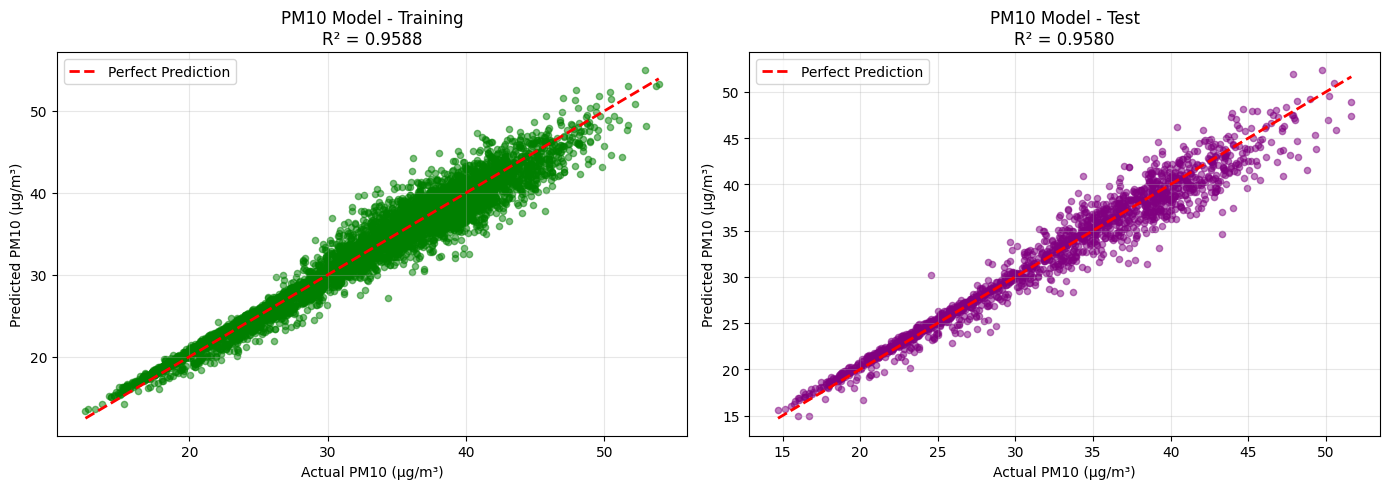

In [33]:
# Visualisasi PM10 Model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training
axes[0].scatter(y_train_pm10, y_train_pred_pm10, alpha=0.5, s=20, color='green')
axes[0].plot([y_train_pm10.min(), y_train_pm10.max()],
             [y_train_pm10.min(), y_train_pm10.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual PM10 (µg/m³)')
axes[0].set_ylabel('Predicted PM10 (µg/m³)')
axes[0].set_title(f'PM10 Model - Training\nR² = {train_r2_pm10:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test_pm10, y_test_pred_pm10, alpha=0.5, s=20, color='purple')
axes[1].plot([y_test_pm10.min(), y_test_pm10.max()],
             [y_test_pm10.min(), y_test_pm10.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual PM10 (µg/m³)')
axes[1].set_ylabel('Predicted PM10 (µg/m³)')
axes[1].set_title(f'PM10 Model - Test\nR² = {test_r2_pm10:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# ========================================
# STEP 3: COMPLETE IMPUTATION SYSTEM
# ========================================

class AirQualityImputer:
    """
    Complete system untuk imputation data kualitas udara
    """
    def __init__(self, pm25_model, pm25_scaler, pm10_model, pm10_scaler, 
                 pm25_stats, pm10_stats):
        self.pm25_model = pm25_model
        self.pm25_scaler = pm25_scaler
        self.pm10_model = pm10_model
        self.pm10_scaler = pm10_scaler
        self.pm25_stats = pm25_stats
        self.pm10_stats = pm10_stats
    
    def is_anomaly(self, value, pollutant='pm25'):
        """Check if value is anomaly"""
        if pollutant == 'pm25':
            stats = self.pm25_stats
        else:
            stats = self.pm10_stats
        
        return detect_anomaly(value, stats['mean'], stats['std'],
                            stats['iqr_low'], stats['iqr_high'])
    
    def impute_pm25(self, pm10, temperature, humidity, pressure):
        """Impute PM2.5 value"""
        input_data = pd.DataFrame([{
            'pm10_density': pm10,
            'temperature': temperature,
            'humidity': humidity,
            'pressure': pressure
        }])
        
        input_scaled = self.pm25_scaler.transform(input_data)
        predicted = self.pm25_model.predict(input_scaled)[0]
        
        # Ensure non-negative
        return max(0.0, predicted)
    
    def impute_pm10(self, pm25, temperature, humidity, pressure):
        """Impute PM10 value"""
        input_data = pd.DataFrame([{
            'pm2.5_density': pm25,
            'temperature': temperature,
            'humidity': humidity,
            'pressure': pressure
        }])
        
        input_scaled = self.pm10_scaler.transform(input_data)
        predicted = self.pm10_model.predict(input_scaled)[0]
        
        # Ensure non-negative
        return max(0.0, predicted)
    
    def process_reading(self, pm25_raw, pm10_raw, temperature, humidity, pressure):
        """
        Process sensor reading dengan automatic imputation
        
        Returns:
        - dict dengan pm25_final, pm10_final, dan status imputation
        """
        result = {
            'pm25_raw': pm25_raw,
            'pm10_raw': pm10_raw,
            'pm25_final': pm25_raw,
            'pm10_final': pm10_raw,
            'pm25_imputed': False,
            'pm10_imputed': False,
            'pm25_status': 'normal',
            'pm10_status': 'normal'
        }
        
        pm25_is_anomaly = self.is_anomaly(pm25_raw, 'pm25')
        pm10_is_anomaly = self.is_anomaly(pm10_raw, 'pm10')
        
        # Case 1: Both anomaly - use historical average or both imputation
        if pm25_is_anomaly and pm10_is_anomaly:
            result['pm25_final'] = self.pm25_stats['mean']
            result['pm10_final'] = self.pm10_stats['mean']
            result['pm25_imputed'] = True
            result['pm10_imputed'] = True
            result['pm25_status'] = 'anomaly_both_bad'
            result['pm10_status'] = 'anomaly_both_bad'
        
        # Case 2: PM2.5 anomaly, PM10 OK
        elif pm25_is_anomaly and not pm10_is_anomaly:
            result['pm25_final'] = self.impute_pm25(pm10_raw, temperature, humidity, pressure)
            result['pm25_imputed'] = True
            result['pm25_status'] = 'anomaly_imputed'
        
        # Case 3: PM10 anomaly, PM2.5 OK
        elif not pm25_is_anomaly and pm10_is_anomaly:
            result['pm10_final'] = self.impute_pm10(pm25_raw, temperature, humidity, pressure)
            result['pm10_imputed'] = True
            result['pm10_status'] = 'anomaly_imputed'
        
        # Case 4: Both normal
        # Do nothing, use original values
        
        return result

# Initialize imputer
imputer = AirQualityImputer(
    pm25_model=ridge_model,
    pm25_scaler=scaler_ridge,
    pm10_model=ridge_pm10,
    pm10_scaler=scaler_pm10,
    pm25_stats=pm25_stats,
    pm10_stats=pm10_stats
)

print("✅ Air Quality Imputer initialized!")

✅ Air Quality Imputer initialized!


In [35]:
# ========================================
# STEP 4: TEST IMPUTATION SYSTEM
# ========================================

print("="*70)
print("TESTING IMPUTATION SYSTEM")
print("="*70)

# Test scenarios
test_scenarios = [
    {
        'name': '✅ Normal readings',
        'pm25': 25.0,
        'pm10': 50.0,
        'temp': 28.0,
        'humid': 65.0,
        'press': 1013.0
    },
    {
        'name': '❌ PM2.5 Anomaly (too high)',
        'pm25': 300.0,
        'pm10': 50.0,
        'temp': 28.0,
        'humid': 65.0,
        'press': 1013.0
    },
    {
        'name': '❌ PM10 Anomaly (negative)',
        'pm25': 25.0,
        'pm10': -10.0,
        'temp': 28.0,
        'humid': 65.0,
        'press': 1013.0
    },
    {
        'name': '❌ Both Anomaly',
        'pm25': 500.0,
        'pm10': -50.0,
        'temp': 28.0,
        'humid': 65.0,
        'press': 1013.0
    },
    {
        'name': '❌ PM2.5 Error (None)',
        'pm25': None,
        'pm10': 60.0,
        'temp': 29.0,
        'humid': 70.0,
        'press': 1012.0
    }
]

for scenario in test_scenarios:
    print(f"\n{scenario['name']}")
    print(f"  Input:  PM2.5={scenario['pm25']}, PM10={scenario['pm10']}")
    
    result = imputer.process_reading(
        pm25_raw=scenario['pm25'],
        pm10_raw=scenario['pm10'],
        temperature=scenario['temp'],
        humidity=scenario['humid'],
        pressure=scenario['press']
    )
    
    print(f"  Output: PM2.5={result['pm25_final']:.2f} [{result['pm25_status']}], " +
          f"PM10={result['pm10_final']:.2f} [{result['pm10_status']}]")
    
    if result['pm25_imputed']:
        print(f"    ⚠️  PM2.5 was imputed")
    if result['pm10_imputed']:
        print(f"    ⚠️  PM10 was imputed")

TESTING IMPUTATION SYSTEM

✅ Normal readings
  Input:  PM2.5=25.0, PM10=50.0
  Output: PM2.5=25.00 [normal], PM10=50.00 [normal]

❌ PM2.5 Anomaly (too high)
  Input:  PM2.5=300.0, PM10=50.0
  Output: PM2.5=25.12 [anomaly_imputed], PM10=50.00 [normal]
    ⚠️  PM2.5 was imputed

❌ PM10 Anomaly (negative)
  Input:  PM2.5=25.0, PM10=-10.0
  Output: PM2.5=25.00 [normal], PM10=54.59 [anomaly_imputed]
    ⚠️  PM10 was imputed

❌ Both Anomaly
  Input:  PM2.5=500.0, PM10=-50.0
  Output: PM2.5=19.38 [anomaly_both_bad], PM10=32.14 [anomaly_both_bad]
    ⚠️  PM2.5 was imputed
    ⚠️  PM10 was imputed

❌ PM2.5 Error (None)
  Input:  PM2.5=None, PM10=60.0
  Output: PM2.5=19.38 [anomaly_both_bad], PM10=32.14 [anomaly_both_bad]
    ⚠️  PM2.5 was imputed
    ⚠️  PM10 was imputed


In [36]:
# ========================================
# STEP 5: SAVE MODELS FOR DEPLOYMENT
# ========================================

import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save models dan scalers
joblib.dump(ridge_model, 'models/pm25_imputer_model.pkl')
joblib.dump(scaler_ridge, 'models/pm25_scaler.pkl')
joblib.dump(ridge_pm10, 'models/pm10_imputer_model.pkl')
joblib.dump(scaler_pm10, 'models/pm10_scaler.pkl')

# Save statistics untuk anomaly detection
import json
stats_to_save = {
    'pm25_stats': pm25_stats,
    'pm10_stats': pm10_stats
}
with open('models/anomaly_stats.json', 'w') as f:
    json.dump(stats_to_save, f, indent=2)

# Save complete imputer object
joblib.dump(imputer, 'models/air_quality_imputer.pkl')

print("✅ Models saved successfully!")
print("\nSaved files:")
print("  📁 models/")
print("    ├── pm25_imputer_model.pkl")
print("    ├── pm25_scaler.pkl")
print("    ├── pm10_imputer_model.pkl")
print("    ├── pm10_scaler.pkl")
print("    ├── anomaly_stats.json")
print("    └── air_quality_imputer.pkl")

# Model size info
for filename in os.listdir('models'):
    filepath = os.path.join('models', filename)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"\n  {filename}: {size_kb:.2f} KB")

✅ Models saved successfully!

Saved files:
  📁 models/
    ├── pm25_imputer_model.pkl
    ├── pm25_scaler.pkl
    ├── pm10_imputer_model.pkl
    ├── pm10_scaler.pkl
    ├── anomaly_stats.json
    └── air_quality_imputer.pkl

  air_quality_imputer.pkl: 2.56 KB

  anomaly_stats.json: 0.47 KB

  pm10_imputer_model.pkl: 0.57 KB

  pm10_scaler.pkl: 1.05 KB

  pm25_imputer_model.pkl: 0.57 KB

  pm25_scaler.pkl: 1.05 KB


In [37]:
# ========================================
# STEP 6: DEPLOYMENT EXAMPLE CODE
# ========================================

deployment_code = '''
# =================================================
# CODE UNTUK DEPLOYMENT DI BACKEND
# =================================================

import joblib
import json
import pandas as pd

# Load model saat startup
imputer = joblib.load('models/air_quality_imputer.pkl')

# Fungsi untuk endpoint API
def process_iot_reading(sensor_data):
    """
    Process IoT sensor reading dengan automatic imputation
    
    Input (sensor_data dict):
    - pm25: PM2.5 density (µg/m³)
    - pm10: PM10 density (µg/m³)
    - temperature: Temperature (°C)
    - humidity: Humidity (%)
    - pressure: Pressure (hPa)
    
    Output:
    - dict dengan data yang sudah diproses dan status imputation
    """
    result = imputer.process_reading(
        pm25_raw=sensor_data.get('pm25'),
        pm10_raw=sensor_data.get('pm10'),
        temperature=sensor_data.get('temperature'),
        humidity=sensor_data.get('humidity'),
        pressure=sensor_data.get('pressure')
    )
    
    # Hitung ISPU
    result['ispu_pm25'] = hitung_ispu(result['pm25_final'], 'PM25')
    result['ispu_pm10'] = hitung_ispu(result['pm10_final'], 'PM10')
    result['ispu'] = max(result['ispu_pm25'], result['ispu_pm10'])
    
    return result

# Contoh penggunaan dalam FastAPI
"""
from fastapi import FastAPI
app = FastAPI()

@app.post("/api/iot/reading")
async def receive_iot_reading(sensor_data: dict):
    # Process dengan imputation
    processed = process_iot_reading(sensor_data)
    
    # Save ke database
    # ... (save logic)
    
    # Return hasil
    return {
        "success": True,
        "data": processed,
        "warnings": [
            "PM2.5 imputed" if processed['pm25_imputed'] else None,
            "PM10 imputed" if processed['pm10_imputed'] else None
        ]
    }
"""
'''

print(deployment_code)

# Save deployment code
with open('models/deployment_example.py', 'w') as f:
    f.write(deployment_code)

print("\n✅ Deployment example saved to: models/deployment_example.py")


# =================================================
# CODE UNTUK DEPLOYMENT DI BACKEND
# =================================================

import joblib
import json
import pandas as pd

# Load model saat startup
imputer = joblib.load('models/air_quality_imputer.pkl')

# Fungsi untuk endpoint API
def process_iot_reading(sensor_data):
    """
    Process IoT sensor reading dengan automatic imputation
    
    Input (sensor_data dict):
    - pm25: PM2.5 density (µg/m³)
    - pm10: PM10 density (µg/m³)
    - temperature: Temperature (°C)
    - humidity: Humidity (%)
    - pressure: Pressure (hPa)
    
    Output:
    - dict dengan data yang sudah diproses dan status imputation
    """
    result = imputer.process_reading(
        pm25_raw=sensor_data.get('pm25'),
        pm10_raw=sensor_data.get('pm10'),
        temperature=sensor_data.get('temperature'),
        humidity=sensor_data.get('humidity'),
        pressure=sensor_data.get('pressure')
    )
    
    # Hitung ISPU
    result['is

## 📊 Model Performance Summary

### PM2.5 Imputation Model
- **Algorithm**: Ridge Regression
- **Features**: PM10, Temperature, Humidity, Pressure
- **Performance**: Lihat cell training di atas

### PM10 Imputation Model  
- **Algorithm**: Ridge Regression
- **Features**: PM2.5, Temperature, Humidity, Pressure
- **Performance**: Lihat cell training di atas

### Anomaly Detection
- **Method**: Combined Z-score (3σ) + IQR (Q1-3×IQR, Q3+3×IQR)
- **Purpose**: Deteksi nilai sensor yang error atau tidak normal

---

## 🚀 Cara Deployment

1. **Copy folder `models/` ke backend Anda**
2. **Install dependencies**:
   ```bash
   pip install scikit-learn==1.3.0 joblib pandas numpy
   ```

3. **Load model di backend**:
   ```python
   import joblib
   imputer = joblib.load('models/air_quality_imputer.pkl')
   ```

4. **Process setiap reading dari IoT**:
   ```python
   result = imputer.process_reading(
       pm25_raw=data['pm25'],
       pm10_raw=data['pm10'],
       temperature=data['temperature'],
       humidity=data['humidity'],
       pressure=data['pressure']
   )
   ```

5. **Save hasil ke database** (gunakan `pm25_final` dan `pm10_final`)

---

## ⚠️ Handling Different Error Scenarios

| Scenario | Action |
|----------|--------|
| PM2.5 error, PM10 OK | Impute PM2.5 dari PM10 + weather |
| PM10 error, PM2.5 OK | Impute PM10 dari PM2.5 + weather |
| Both error | Use historical averages |
| Both OK but anomaly | Impute yang anomaly |
| Both OK | Use original values |

## 🚀 Deployment ke Vercel - Testing API

Sekarang kita akan test API yang sudah digabungkan dengan endpoint imputation

In [ ]:
# ========================================
# TEST API LOCALLY
# ========================================

# Contoh test request untuk endpoint /impute
test_request_impute = {
    "pm25": 25.5,
    "pm10": 60.0,
    "temperature": 28.5,
    "humidity": 65.0,
    "pressure": 1013.0
}

print("🧪 TEST REQUEST - Normal Reading:")
print(json.dumps(test_request_impute, indent=2))

# Test dengan anomaly
test_request_anomaly = {
    "pm25": 500.0,  # Anomaly - too high
    "pm10": -10.0,   # Anomaly - negative
    "temperature": 28.5,
    "humidity": 65.0,
    "pressure": 1013.0
}

print("\n🧪 TEST REQUEST - Anomaly Reading:")
print(json.dumps(test_request_anomaly, indent=2))

print("\n" + "="*70)
print("📝 CARA MENJALANKAN API:")
print("="*70)
print("\n1. Pastikan semua model sudah disave di folder models/")
print("2. Copy file app_simple.py ke folder ml/")
print("3. Install dependencies:")
print("   pip install fastapi uvicorn joblib scikit-learn pandas numpy")
print("\n4. Jalankan API:")
print("   python app_simple.py")
print("\n5. Test API di browser atau Postman:")
print("   - GET  http://localhost:8001/status")
print("   - POST http://localhost:8001/impute")
print("   - POST http://localhost:8001/predict")
print("\n6. Untuk deploy ke Vercel:")
print("   - Upload models ke GitHub releases atau cloud storage")
print("   - Update MODEL_URLS di app_simple.py")
print("   - Deploy ke Vercel dengan vercel.json")
print("="*70)

In [38]:
# ========================================
# BUAT SAMPLE TEST FILE JSON
# ========================================

# Create Test API folder if not exists
import os
os.makedirs('Test API', exist_ok=True)

# Sample request untuk testing /impute endpoint
sample_normal = {
    "pm25": 25.5,
    "pm10": 60.0,
    "temperature": 28.5,
    "humidity": 65.0,
    "pressure": 1013.0,
    "timestamp": "2026-02-02T10:00:00"
}

sample_pm25_anomaly = {
    "pm25": 500.0,  # Too high
    "pm10": 60.0,
    "temperature": 28.5,
    "humidity": 65.0,
    "pressure": 1013.0,
    "timestamp": "2026-02-02T10:00:00"
}

sample_pm10_anomaly = {
    "pm25": 25.5,
    "pm10": -10.0,  # Negative (error)
    "temperature": 28.5,
    "humidity": 65.0,
    "pressure": 1013.0,
    "timestamp": "2026-02-02T10:00:00"
}

sample_both_error = {
    "pm25": None,  # Null/Error
    "pm10": None,  # Null/Error
    "temperature": 28.5,
    "humidity": 65.0,
    "pressure": 1013.0,
    "timestamp": "2026-02-02T10:00:00"
}

# Save to files
with open('Test API/sample_normal_reading.json', 'w') as f:
    json.dump(sample_normal, f, indent=2)

with open('Test API/sample_pm25_anomaly.json', 'w') as f:
    json.dump(sample_pm25_anomaly, f, indent=2)

with open('Test API/sample_pm10_anomaly.json', 'w') as f:
    json.dump(sample_pm10_anomaly, f, indent=2)

with open('Test API/sample_both_error.json', 'w') as f:
    json.dump(sample_both_error, f, indent=2)

print("✅ Sample test files created in Test API/ folder:")
print("   - sample_normal_reading.json")
print("   - sample_pm25_anomaly.json")
print("   - sample_pm10_anomaly.json")
print("   - sample_both_error.json")

print("\n📝 Cara testing dengan curl:")
print("\ncurl -X POST http://localhost:8001/impute \\")
print('  -H "Content-Type: application/json" \\')
print('  -d @"Test API/sample_normal_reading.json"')

✅ Sample test files created in Test API/ folder:
   - sample_normal_reading.json
   - sample_pm25_anomaly.json
   - sample_pm10_anomaly.json
   - sample_both_error.json

📝 Cara testing dengan curl:

curl -X POST http://localhost:8001/impute \
  -H "Content-Type: application/json" \
  -d @"Test API/sample_normal_reading.json"
